# Red Neuronal con TensorFlow

Entrena una red neuronal densa con **TensorFlow/Keras** para predecir `imdb_clase` (calidad percibida por audiencia): Bajo / Medio / Alto.

**Mejoras respecto al MLPClassifier:**
- Framework: TensorFlow 2.x con arquitectura Keras Sequential
- Feature adicional: `rotten_tomatoes_score` (calificacion de criticos, distinta al target que mide audiencia IMDb)
- Class weights balanceados para corregir el sesgo hacia la clase Medio (~50% del dataset)
- Dropout en capas ocultas para regularizacion
- `ReduceLROnPlateau` para entrenamiento mas largo sin sobreajuste
- `EarlyStopping` con `restore_best_weights=True`

**Nota:** `imdb_rating` sigue excluido del feature set (es la fuente directa del target `imdb_clase`).

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
from src.preprocessing import codificar_categoricas, COLUMNAS_CATEGORICAS, COLUMNAS_NUMERICAS

print(f'TensorFlow: {tf.__version__}')
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow: 2.21.0


## 1. Cargar datos y preparar features

Se carga el catalogo procesado y se construye el feature set incluyendo `rotten_tomatoes_score`.
A diferencia del pipeline anterior, aqui se construye el dataset directamente desde el catalogo
para poder incluir RT score sin afectar el pipeline de clasificacion binaria (is_hit).

In [2]:
df = pd.read_csv('../data/processed/catalogo_procesado.csv')
df, encoders = codificar_categoricas(df, COLUMNAS_CATEGORICAS)

# Features: numericas base + categoricas codificadas + rotten_tomatoes_score
FEATURES_NN_TF = COLUMNAS_NUMERICAS + ['platform_cod', 'primary_genre_cod', 'rating_cod', 'rotten_tomatoes_score']

# Target
df['imdb_clase_cod'] = df['imdb_clase'].map({'Bajo': 0, 'Medio': 1, 'Alto': 2})

print(f'Dataset: {df.shape}')
print(f'Features: {len(FEATURES_NN_TF)} columnas')
print(f'Nulos en features: {df[FEATURES_NN_TF].isnull().sum().sum()}')
print()
print('Balance de clases:')
conteo = df['imdb_clase_cod'].value_counts().sort_index()
for i, nombre in enumerate(['Bajo', 'Medio', 'Alto']):
    pct = conteo[i] / len(df) * 100
    print(f'  {nombre}: {conteo[i]} ({pct:.1f}%)')

Dataset: (15000, 42)
Features: 17 columnas
Nulos en features: 0

Balance de clases:
  Bajo: 4150 (27.7%)
  Medio: 7518 (50.1%)
  Alto: 3332 (22.2%)


## 2. Split, escalado y pesos de clase

Split 80/20 estratificado con `random_state=42`.
Los pesos de clase balanceados hacen que la red preste igual atencion a Bajo, Medio y Alto,
corrigiendo el sesgo del modelo anterior que casi siempre predecia "Medio".

In [3]:
X = df[FEATURES_NN_TF].values
y = df['imdb_clase_cod'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Pesos inversamente proporcionales a la frecuencia de cada clase
clases = np.unique(y_train)
pesos  = compute_class_weight('balanced', classes=clases, y=y_train)
class_weight = dict(zip(clases.tolist(), pesos.tolist()))

print(f'Train: {X_train.shape}   Test: {X_test.shape}')
print()
print('Pesos de clase (balanced):')
for i, nombre in enumerate(['Bajo', 'Medio', 'Alto']):
    print(f'  {nombre}: {class_weight[i]:.3f}')

Train: (12000, 17)   Test: (3000, 17)

Pesos de clase (balanced):
  Bajo: 1.205
  Medio: 0.665
  Alto: 1.500


In [4]:
modelo = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(3, activation='softmax'),
], name='clasificador_imdb')

modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

modelo.summary()

Model: "clasificador_imdb"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,755 (42.01 KB)

 Trainable params: 10,755 (42.01 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento

`EarlyStopping` con `patience=20` y `restore_best_weights=True` para recuperar el mejor modelo.
`ReduceLROnPlateau` reduce el learning rate cuando la validacion se estanca,
permitiendo convergencia mas lenta pero mas robusta que el MLPClassifier (que paro en 24 iteraciones).

In [5]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = modelo.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=300,
    batch_size=256,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=0,
)

print(f'Epocas entrenadas: {len(history.history["loss"])}')
print(f'Mejor val_accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'Mejor val_loss:     {min(history.history["val_loss"]):.4f}')


Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.



Epoch 39: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


Epoch 43: early stopping


Restoring model weights from the end of the best epoch: 23.


Epocas entrenadas: 43
Mejor val_accuracy: 0.6608
Mejor val_loss:     0.6909


## 4. Curva de entrenamiento

Loss y accuracy en entrenamiento y validacion a lo largo de las epocas.

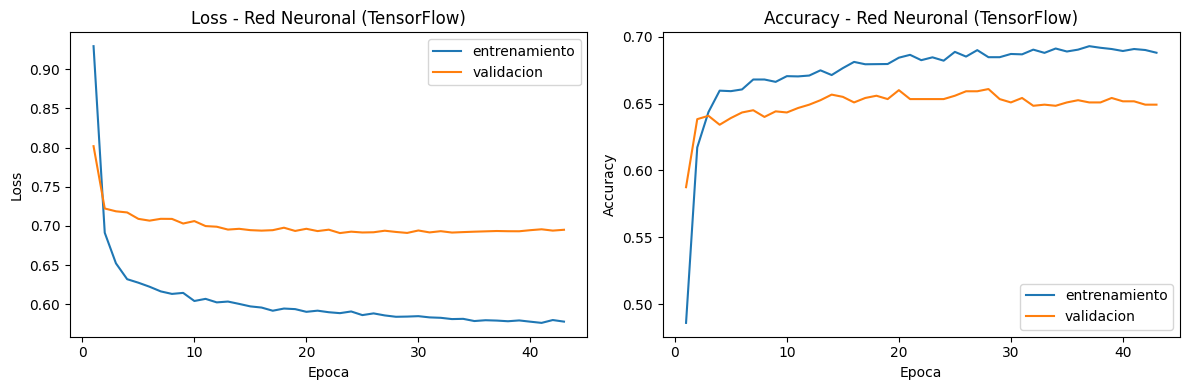

In [6]:
epocas = range(1, len(history.history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epocas, history.history['loss'], label='entrenamiento')
ax1.plot(epocas, history.history['val_loss'], label='validacion')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Loss')
ax1.set_title('Loss - Red Neuronal (TensorFlow)')
ax1.legend()

ax2.plot(epocas, history.history['accuracy'], label='entrenamiento')
ax2.plot(epocas, history.history['val_accuracy'], label='validacion')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy - Red Neuronal (TensorFlow)')
ax2.legend()

plt.tight_layout()
plt.savefig('../reports/figures/16_loss_curve_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Metricas en test

Con class weights, el modelo deberia mejorar significativamente el recall de las clases minoritarias
Bajo y Alto, a costa de reducir un poco el recall de Medio.

In [7]:
y_proba = modelo.predict(X_test, verbose=0)
y_pred  = y_proba.argmax(axis=1)
nombres_clases = ['Bajo', 'Medio', 'Alto']

accuracy   = float((y_pred == y_test).mean())
f1_macro   = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy:    {accuracy:.4f}')
print(f'F1-macro:    {f1_macro:.4f}')
print(f'F1-weighted: {f1_weighted:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=nombres_clases))

Accuracy:    0.6760
F1-macro:    0.6844
F1-weighted: 0.6707

              precision    recall  f1-score   support

        Bajo       0.63      0.83      0.71       830
       Medio       0.74      0.55      0.63      1504
        Alto       0.66      0.78      0.71       666

    accuracy                           0.68      3000
   macro avg       0.67      0.72      0.68      3000
weighted avg       0.69      0.68      0.67      3000



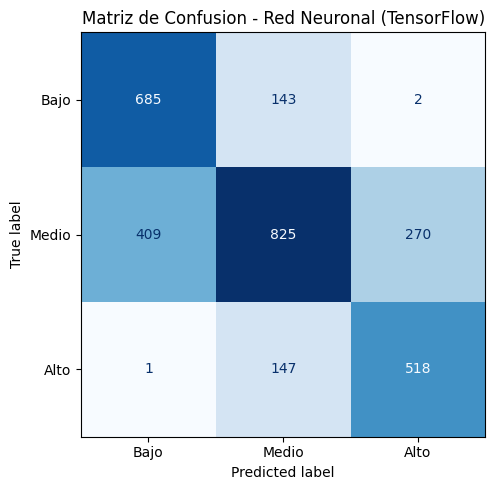

In [8]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=nombres_clases).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusion - Red Neuronal (TensorFlow)')
plt.tight_layout()
plt.savefig('../reports/figures/conf_matrix_mlp.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Guardar modelo

In [9]:
# Guardar modelo en formato Keras nativo
modelo.save('../models/mlp.keras')

# Actualizar scaler_nn con el nuevo feature set (17 features)
joblib.dump(scaler, '../models/scaler_nn.joblib')

# Actualizar features_config.json
with open('../models/features_config.json', 'r') as f:
    config = json.load(f)
config['FEATURES_NN'] = FEATURES_NN_TF
with open('../models/features_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Actualizar metricas.json
with open('../models/metricas.json', 'r') as f:
    metricas = json.load(f)

metricas['mlp'] = {
    'modelo': 'Red Neuronal (TensorFlow)',
    'target': 'imdb_clase',
    'accuracy': round(accuracy, 4),
    'f1_macro': round(float(f1_macro), 4),
    'f1_weighted': round(float(f1_weighted), 4),
    'arquitectura': '128-Dropout(0.3)-64-Dropout(0.2)-3',
    'n_features': len(FEATURES_NN_TF),
    'incluye_rt_score': True,
    'epochs': len(history.history['loss']),
}

with open('../models/metricas.json', 'w') as f:
    json.dump(metricas, f, indent=2)

print('Modelo guardado: models/mlp.keras')
print('Scaler actualizado: models/scaler_nn.joblib')
print('Metricas actualizadas: models/metricas.json')
print()
print(metricas['mlp'])

Modelo guardado: models/mlp.keras
Scaler actualizado: models/scaler_nn.joblib
Metricas actualizadas: models/metricas.json

{'modelo': 'Red Neuronal (TensorFlow)', 'target': 'imdb_clase', 'accuracy': 0.676, 'f1_macro': 0.6844, 'f1_weighted': 0.6707, 'arquitectura': '128-Dropout(0.3)-64-Dropout(0.2)-3', 'n_features': 17, 'incluye_rt_score': True, 'epochs': 43}
